<div dir="rtl" style="text-align: center; line-height: 2; font-family: Tahoma;">
    <b style="font-size: 20px;">آزمون فرض ۴</b>
</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
در این آزمون، امکانات موجود در آگهی‌ها را به دو دسته امکانات لاکچری و امکانات غیرلاکچری تقسیم می‌کنیم. فرضیه ما این است که میانگین مبلغ قیمت برای وجود ویژگی‌های لاکچری افزایش چشمگیری دارد. می‌خواهیم بررسی کنیم که آیا این میانگین برای وجود امکانات غیرلاکچری نیز تفاوت معناداری دارد یا خیر.
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('Divar_Iran.csv', low_memory=False)

In [3]:
lux_features = [
    "has_pool",
    "has_barbecue",
    "has_sauna",
    "has_jacuzzi"
]

non_lux_features = [
    "has_balcony",
    "has_elevator",
    "has_warehouse",
    "has_parking"
]

price_col = "price_value"
needed_cols = [price_col] + lux_features + non_lux_features

In [4]:
df_selected = df[needed_cols].copy()
df_selected.shape

(995939, 9)

In [5]:
for col in lux_features + non_lux_features:
    print("\n", col)
    print(df_selected[col].value_counts(dropna=False).head(10))


 has_pool
has_pool
NaN      966657
False     25578
True       3704
Name: count, dtype: int64

 has_barbecue
has_barbecue
NaN      964851
False     23289
True       7799
Name: count, dtype: int64

 has_sauna
has_sauna
NaN      967567
False     26982
True       1390
Name: count, dtype: int64

 has_jacuzzi
has_jacuzzi
NaN      967318
False     26359
True       2262
Name: count, dtype: int64

 has_balcony
has_balcony
NaN         491172
true        390856
false        88529
True         20630
False         4529
unselect       223
Name: count, dtype: int64

 has_elevator
has_elevator
NaN      456402
True     363397
False    176140
Name: count, dtype: int64

 has_warehouse
has_warehouse
True     580930
NaN      270573
False    144436
Name: count, dtype: int64

 has_parking
has_parking
True     550316
NaN      270572
False    175051
Name: count, dtype: int64


In [6]:
bool_map = {
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
    "true": 1,
    "false": 0,
    "TRUE": 1,
    "FALSE": 0,
    1: 1,
    0: 0,
    "1": 1,
    "0": 0
}

for col in lux_features + non_lux_features:
    df_selected[col] = df_selected[col].map(bool_map)

In [7]:
df_selected[price_col] = pd.to_numeric(df_selected[price_col], errors="coerce")

In [8]:
price_check = df_selected[price_col].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)
price_check

count    5.663770e+05
mean     1.736190e+10
std      5.885228e+11
min      0.000000e+00
1%       3.400000e+03
5%       2.600000e+08
25%      1.400000e+09
50%      2.830000e+09
75%      5.900000e+09
95%      2.100000e+10
99%      8.500000e+10
max      1.000000e+14
Name: price_value, dtype: float64

In [9]:
def has_any_feature(row):
    valid = row.dropna()
    
    if len(valid) == 0:
        return np.nan
    
    return int((valid == 1).any())

In [10]:
df_selected["has_lux"] = df_selected[lux_features].apply(has_any_feature, axis=1)
df_selected["has_non_lux"] = df_selected[non_lux_features].apply(has_any_feature, axis=1)

In [11]:
df_selected.head()

,price_value,has_pool,has_barbecue,has_sauna,has_jacuzzi,has_balcony,has_elevator,has_warehouse,has_parking,has_lux,has_non_lux
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,1.0
2,8.700000e+09,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,1.0
3,6.500000e+08,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,1.0
4,2.600000e+09,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,1.0


In [12]:
print("Luxury groups:")
print(df_selected["has_lux"].value_counts(dropna=False))

print("\nNon-luxury groups:")
print(df_selected["has_non_lux"].value_counts(dropna=False))

Luxury groups:
has_lux
NaN    964548
0.0     22773
1.0      8618
Name: count, dtype: int64

Non-luxury groups:
has_non_lux
1.0    685516
NaN    270572
0.0     39851
Name: count, dtype: int64


In [13]:
df_selected = df_selected.dropna(subset=[price_col]).copy()
df_selected = df_selected[df_selected[price_col] > 0]

In [14]:
df_selected[price_col].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    5.644830e+05
mean     1.742016e+10
std      5.895084e+11
min      1.000000e+00
1%       1.111110e+05
5%       3.000000e+08
25%      1.404000e+09
50%      2.850000e+09
75%      5.913000e+09
95%      2.100000e+10
99%      8.581055e+10
max      1.000000e+14
Name: price_value, dtype: float64

In [15]:
print("Luxury groups with valid price:")
print(df_selected["has_lux"].value_counts(dropna=False))

print("\nNon-luxury groups with valid price:")
print(df_selected["has_non_lux"].value_counts(dropna=False))

Luxury groups with valid price:
has_lux
NaN    542621
0.0     15618
1.0      6244
Name: count, dtype: int64

Non-luxury groups with valid price:
has_non_lux
1.0    412583
NaN    138072
0.0     13828
Name: count, dtype: int64


In [16]:
def group_summary(data, group_col, price_col):
    temp = data[[group_col, price_col]].dropna()

    return temp.groupby(group_col)[price_col].agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q01=lambda x: x.quantile(0.01),
        q05=lambda x: x.quantile(0.05),
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q95=lambda x: x.quantile(0.95),
        q99=lambda x: x.quantile(0.99),
        max="max",
        skew="skew"
    )

In [17]:
lux_summary = group_summary(df_selected, "has_lux", price_col)
non_lux_summary = group_summary(df_selected, "has_non_lux", price_col)

In [18]:
lux_summary

,count,mean,median,std,min,q01,q05,q25,q75,q95,q99,max,skew
has_lux,,,,,,,,,,,,,
0.0,15618,1.545469e+10,2.700000e+09,8.183620e+11,1.0,1111.0,317000000.0,1.500000e+09,5.000000e+09,1.500000e+10,5.283000e+10,1.000000e+14,117.315645
1.0,6244,1.168208e+10,2.997500e+09,2.913851e+11,1.0,111111.0,700000000.0,1.800000e+09,5.800000e+09,1.800000e+10,5.557000e+10,2.000000e+13,60.625672


In [19]:
non_lux_summary

,count,mean,median,std,min,q01,q05,q25,q75,q95,q99,max,skew
has_non_lux,,,,,,,,,,,,,
0.0,13828,8.647204e+09,1.380000e+09,2.235555e+11,1.0,552.7,11111111.0,8.500000e+08,2.376250e+09,6.500000e+09,1.950000e+10,1.111111e+13,43.228901
1.0,412583,1.589543e+10,3.240000e+09,5.350456e+11,1.0,111111.0,710000000.0,1.800000e+09,6.300000e+09,2.000000e+10,6.000000e+10,1.000000e+14,122.299837


In [20]:
def plot_group_price_distribution(data, group_col, price_col, title):
    temp = data[[group_col, price_col]].dropna().copy()

    q99 = temp[price_col].quantile(0.99)
    temp_plot = temp[temp[price_col] <= q99]

    group_0 = temp_plot.loc[temp_plot[group_col] == 0, price_col]
    group_1 = temp_plot.loc[temp_plot[group_col] == 1, price_col]

    plt.figure(figsize=(8, 4))
    plt.boxplot(
        [group_0, group_1],
        labels=["No", "Yes"],
        showfliers=False
    )
    plt.xlabel(group_col)
    plt.ylabel(price_col)
    plt.title(title + " - Boxplot up to 99th percentile")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(group_0, bins=60, alpha=0.6, label="No", density=True)
    plt.hist(group_1, bins=60, alpha=0.6, label="Yes", density=True)
    plt.xlabel(price_col)
    plt.ylabel("Density")
    plt.title(title + " - Histogram up to 99th percentile")
    plt.legend()
    plt.show()

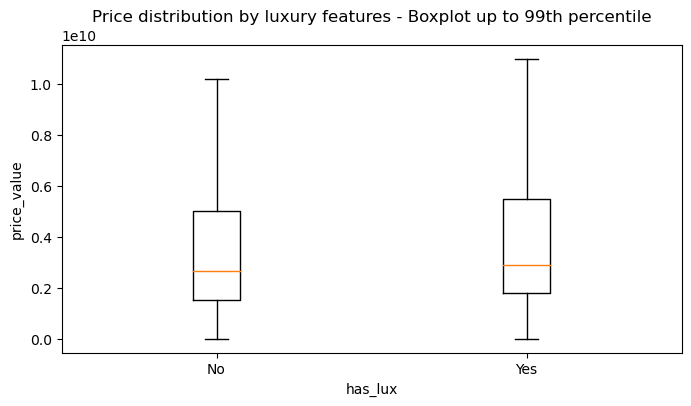

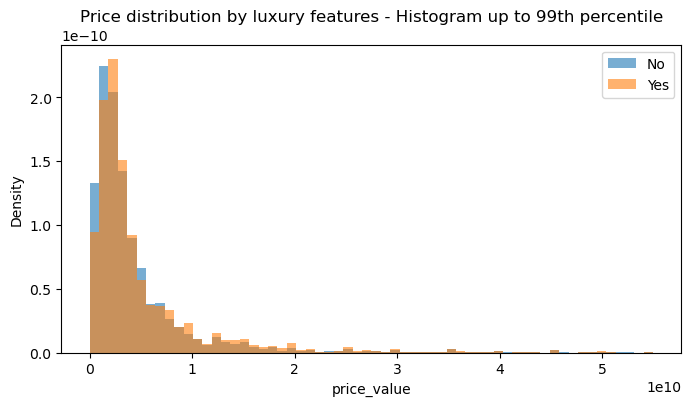

In [21]:
plot_group_price_distribution(
    df_selected,
    "has_lux",
    price_col,
    "Price distribution by luxury features"
)

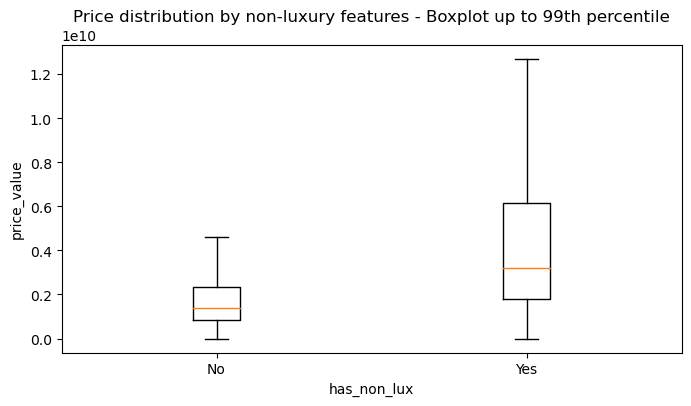

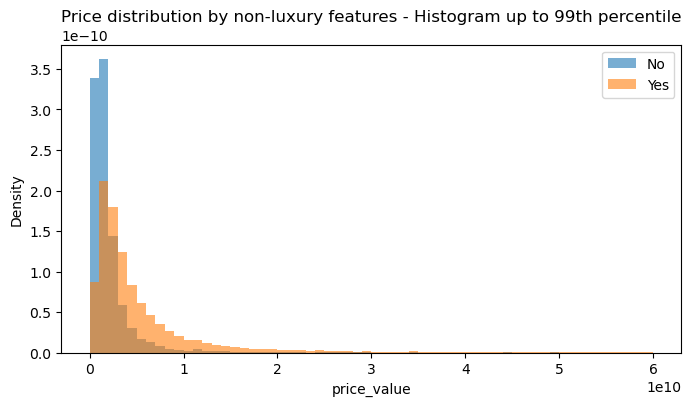

In [22]:
plot_group_price_distribution(
    df_selected,
    "has_non_lux",
    price_col,
    "Price distribution by non-luxury features"
)

In [23]:
df_test = df_selected.copy()

q01 = df_test[price_col].quantile(0.01)
q99 = df_test[price_col].quantile(0.99)

df_test = df_test[
    (df_test[price_col] >= q01) &
    (df_test[price_col] <= q99)
].copy()

In [24]:
q01, q99, df_test.shape

(111111.0, 85810549068.843, (553696, 11))

In [25]:
lux_summary = group_summary(df_test, "has_lux", price_col)
non_lux_summary = group_summary(df_test, "has_non_lux", price_col)

In [26]:
lux_summary

,count,mean,median,std,min,q01,q05,q25,q75,q95,q99,max,skew
has_lux,,,,,,,,,,,,,
0.0,15230,4.670195e+09,2.700000e+09,6.773177e+09,111111.0,1.111111e+06,650000000.0,1.600000e+09,5.000000e+09,1.485500e+10,3.500000e+10,8.500000e+10,5.229724
1.0,6162,5.208105e+09,3.000000e+09,7.267052e+09,111111.0,1.067778e+08,781000000.0,1.800000e+09,5.630000e+09,1.700000e+10,3.600000e+10,8.500000e+10,4.689889


In [27]:
non_lux_summary

,count,mean,median,std,min,q01,q05,q25,q75,q95,q99,max,skew
has_non_lux,,,,,,,,,,,,,
0.0,13432,2.214005e+09,1.400000e+09,3.562588e+09,111111.0,1000000.0,247750000.0,9.000000e+08,2.400000e+09,6.345050e+09,1.500000e+10,8.000000e+10,9.676832
1.0,405773,5.691456e+09,3.250000e+09,7.845068e+09,111111.0,4287200.0,800000000.0,1.830000e+09,6.272500e+09,1.850000e+10,4.250000e+10,8.580000e+10,4.377870


<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
<b>آزمون اول</b>
</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
<b>فرض صفر:</b>
میانگین قیمت خانه‌های دارای امکانات لوکس با میانگین قیمت خانه‌های فاقد امکانات لوکس تفاوت معناداری ندارد.
</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
<b>فرض جایگزین:</b>
میانگین قیمت خانه‌های دارای امکانات لوکس با میانگین قیمت خانه‌های فاقد امکانات لوکس تفاوت معناداری دارد.
</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
<b>آزمون دوم</b>
</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
<b>فرض صفر:</b>
میانگین قیمت خانه‌های دارای امکانات غیرلوکس با میانگین قیمت خانه‌های فاقد امکانات غیرلوکس تفاوت معناداری ندارد.
</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
<b>فرض جایگزین:</b>
میانگین قیمت خانه‌های دارای امکانات غیرلوکس با میانگین قیمت خانه‌های فاقد امکانات غیرلوکس تفاوت معناداری دارد.
</div>

In [28]:
def welch_test(data, group_col, price_col):
    temp = data[[group_col, price_col]].dropna()
    
    group_no = temp.loc[temp[group_col] == 0, price_col]
    group_yes = temp.loc[temp[group_col] == 1, price_col]
    
    test = stats.ttest_ind(
        group_yes,
        group_no,
        equal_var=False
    )
    
    mean_no = group_no.mean()
    mean_yes = group_yes.mean()
    mean_diff = mean_yes - mean_no
    pct_diff = (mean_diff / mean_no) * 100
    
    return {
        "group": group_col,
        "n_no": len(group_no),
        "n_yes": len(group_yes),
        "mean_no": mean_no,
        "mean_yes": mean_yes,
        "mean_diff": mean_diff,
        "pct_diff": pct_diff,
        "t_stat": test.statistic,
        "p_value": test.pvalue
    }

In [29]:
welch_results = pd.DataFrame([
    welch_test(df_test, "has_lux", price_col),
    welch_test(df_test, "has_non_lux", price_col)
])

welch_results

,group,n_no,n_yes,mean_no,mean_yes,mean_diff,pct_diff,t_stat,p_value
0,has_lux,15230,6162,4.670195e+09,5.208105e+09,5.379102e+08,11.517938,4.998145,5.879920e-07
1,has_non_lux,13432,405773,2.214005e+09,5.691456e+09,3.477451e+09,157.066052,105.012271,0.000000e+00


<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
در این بخش علاوه بر آزمون Welch، از آزمون Mann-Whitney U نیز استفاده می‌کنیم. 
آزمون Welch برای بررسی تفاوت میانگین قیمت بین دو گروه مناسب است، مخصوصاً وقتی واریانس و تعداد نمونه‌های دو گروه برابر نیستند. 
اما چون توزیع قیمت ملک چوله و دارای مقادیر پرت است، آزمون Mann-Whitney نیز به عنوان یک آزمون ناپارامتری استفاده می‌شود تا تفاوت کلی توزیع یا رتبه‌های قیمت بین دو گروه بررسی شود.
</div>

In [30]:
def mann_whitney_test(data, group_col, price_col):
    temp = data[[group_col, price_col]].dropna()
    
    group_no = temp.loc[temp[group_col] == 0, price_col]
    group_yes = temp.loc[temp[group_col] == 1, price_col]
    
    test = stats.mannwhitneyu(
        group_yes,
        group_no,
        alternative="two-sided"
    )
    
    mean_no = group_no.mean()
    mean_yes = group_yes.mean()
    mean_diff = mean_yes - mean_no
    pct_mean_diff = (mean_diff / mean_no) * 100
    
    median_no = group_no.median()
    median_yes = group_yes.median()
    median_diff = median_yes - median_no
    pct_median_diff = (median_diff / median_no) * 100
    
    return {
        "group": group_col,
        "n_no": len(group_no),
        "n_yes": len(group_yes),
        "mean_no": mean_no,
        "mean_yes": mean_yes,
        "mean_diff": mean_diff,
        "pct_mean_diff": pct_mean_diff,
        "median_no": median_no,
        "median_yes": median_yes,
        "median_diff": median_diff,
        "pct_median_diff": pct_median_diff,
        "u_stat": test.statistic,
        "p_value": test.pvalue
    }

In [31]:
mann_results = pd.DataFrame([
    mann_whitney_test(df_test, "has_lux", price_col),
    mann_whitney_test(df_test, "has_non_lux", price_col)
])

mann_results

,group,n_no,n_yes,mean_no,mean_yes,mean_diff,pct_mean_diff,median_no,median_yes,median_diff,pct_median_diff,u_stat,p_value
0,has_lux,15230,6162,4.670195e+09,5.208105e+09,5.379102e+08,11.517938,2.700000e+09,3.000000e+09,3.000000e+08,11.111111,4.983169e+07,1.155930e-12
1,has_non_lux,13432,405773,2.214005e+09,5.691456e+09,3.477451e+09,157.066052,1.400000e+09,3.250000e+09,1.850000e+09,132.142857,4.145001e+09,0.000000e+00


<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
نتایج آزمون Welch نشان می‌دهد که میانگین قیمت در گروه دارای امکانات لوکس نسبت به گروه فاقد امکانات لوکس به طور معناداری بیشتر است. 
همچنین آزمون Mann-Whitney U نیز این تفاوت را تأیید می‌کند و نشان می‌دهد توزیع قیمت‌ها در دو گروه تفاوت معنادار دارد.
</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
برای امکانات غیرلوکس نیز هر دو آزمون مقدار p-value بسیار کوچکی دارند؛ بنابراین تفاوت قیمت بین خانه‌های دارای امکانات غیرلوکس و فاقد این امکانات از نظر آماری معنادار است. 
نکته مهم این است که درصد اختلاف میانگین برای امکانات غیرلوکس بسیار بیشتر از امکانات لوکس است. بنابراین در این داده‌ها، امکانات پایه‌ای مانند پارکینگ، آسانسور، انباری و بالکن ارتباط قوی‌تری با افزایش قیمت دارند.
</div>